In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
#!wget $data
!curl -O $data

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1440k  100 1440k    0     0  5123k      0 --:--:-- --:--:-- --:--:-- 5146k


In [3]:
df = pd.read_csv('data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [4]:
## Cleanup & Data Preparation

df.columns = df.columns.str.lower().str.replace(' ','_')
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [5]:
## cleaning up the values within a single column. 
## first identify the list of all column names that are string. 
## then loop through the values inside that column name to make updates 

strings = list(df.dtypes[df.dtypes == 'str'].index)
for col in strings: 
    df[col] = df[col].str.lower().str.replace(' ','_')

In [6]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


* Exploratory Data Analysis*

In [7]:
for col in df.columns: 
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

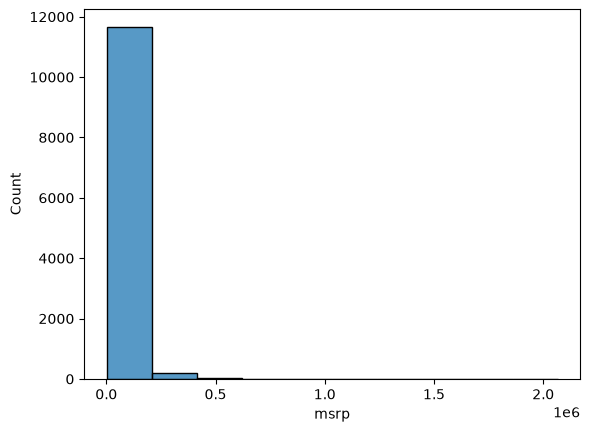

In [9]:
sns.histplot(df.msrp,bins=10)

<Axes: xlabel='msrp', ylabel='Count'>

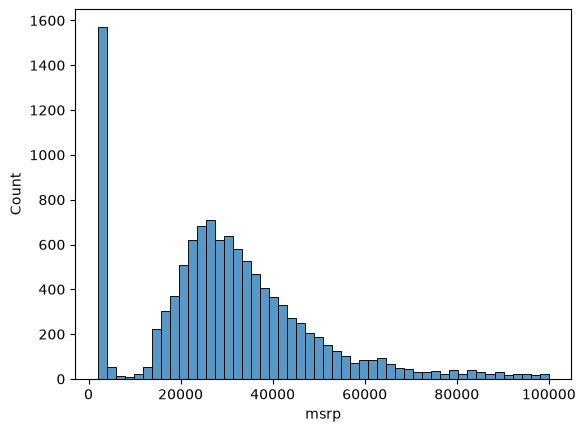

In [10]:
sns.histplot(df.msrp[df.msrp < 100000],bins=50)

<Axes: xlabel='msrp', ylabel='Count'>

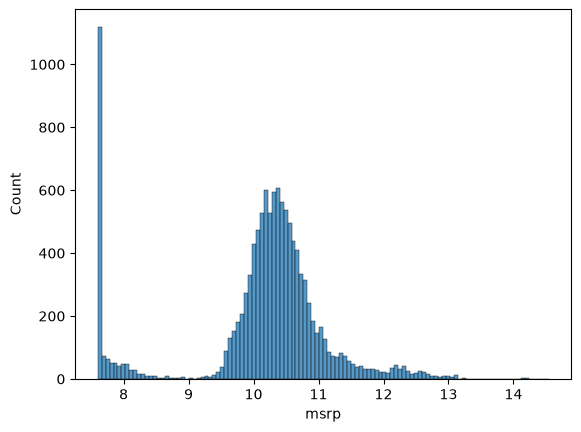

In [11]:
## applying log to all MSRP values will shrink them
## log of 0 is not defined so add +1 to each value to compute the log

price_logs = np.log1p(df.msrp)
price_logs
sns.histplot(price_logs)

In [12]:
## identify missing values in each column
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [13]:
n = int(len(df))

n_train = int(len(df)*0.6)
n_val = int(len(df)*0.2)
n_test = n - n_train - n_val

n, n_val+n_train+n_test

(11914, 11914)

In [14]:
n_val, n_test, n_train

(2382, 2384, 7148)

In [15]:
# Split the dataset into validation, test, and train sets by row position.
# iloc selects by integer position (0, 1, 2, ...), not by index label.
# Slices are start-inclusive, stop-exclusive, so the three ranges below
# are contiguous and non-overlapping:
#   val   -> positions [0, n_val)
#   test  -> positions [n_val, n_val + n_test)
#   train -> positions [n_val + n_test, end)
# Note: df should be shuffled beforehand (e.g. df.sample(frac=1, random_state=42)),
# otherwise each split just takes rows in their original order.


df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]


len(df_train)

7148

In [16]:
##Shuffling the rows of the data frame

idx = np.arange(n)
np.random.seed(2) ##helps make the random shuffling consistent for this notebook
np.random.shuffle(idx)
idx

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

len(df_train), len(df_val), len(df_test)



(7148, 2382, 2384)

In [17]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,14410
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,19685
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,19795
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,2000
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,56260


In [18]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_test

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,mitsubishi,lancer,2016,regular_unleaded,148.0,4.0,manual,front_wheel_drive,4.0,NaN,compact,sedan,34,24,436,17595
1,kia,sorento,2015,regular_unleaded,290.0,6.0,automatic,front_wheel_drive,4.0,crossover,midsize,4dr_suv,25,18,1720,26700
2,gmc,vandura,1994,regular_unleaded,165.0,6.0,automatic,rear_wheel_drive,3.0,NaN,compact,cargo_van,20,15,549,2000
3,mercedes-benz,600-class,1993,regular_unleaded,389.0,12.0,automatic,rear_wheel_drive,2.0,luxury,large,coupe,15,11,617,3211
4,toyota,venza,2013,regular_unleaded,268.0,6.0,automatic,all_wheel_drive,4.0,"crossover,performance",midsize,wagon,25,18,2031,31120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2379,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
2380,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
2381,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
2382,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [19]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)


In [20]:
del df_train["msrp"]
del df_val["msrp"]
del df_test["msrp"]


In [21]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7143,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61
7144,cadillac,dts,2010,premium_unleaded_(recommended),275.0,8.0,automatic,front_wheel_drive,4.0,luxury,large,sedan,23,15,1624
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873


In [22]:
## looking at a specific row
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [23]:
xi = [453, 11, 86]

w0 = 0
w = [1, 1, 1]

In [24]:
## defining the linear regression function 

def linear_regression(xi): 

#the summation function to multiply the weights with each feature and summing them up
    n = len(xi) # finds the length of the vector containing the features

    pred = w0 # initializing the preduction with a zero value
    for j in range(n): #iterating over the whole range for the summation function 
        pred = pred + w[j] * xi[j] #for each positional term in the matrix xi (features) and w(weights), we take a sumproduct

    return pred #returns the final value with the weighted sum

linear_regression(xi)

550

In [25]:
## Linear Regression in vector form — Approach 1: bias term kept separate
#
# g(xi) = w0 + xi1*w1 + xi2*w2 + ... + xin*wn
#       = w0 + (xi · w)          <- bias + dot product of feature and weight vectors
#
# xi : feature vector for one observation, e.g. [xi1, xi2, ..., xin]
# w  : weight vector, one weight per feature, e.g. [w1, w2, ..., wn]
# w0 : bias / intercept, handled separately from the dot product

def dot_product(xi, w):
    # Multiply matching elements and add them up: xi1*w1 + xi2*w2 + ...
    n = len(xi)          # number of features (computed from the input, so it works for any length)
    result = 0           # running total, reset on every call
    
    for j in range(n):
        result = result + w[j] * xi[j]
    return result

def lin_reg(xi, w):
    # Prediction = bias + weighted sum of features.
    # Note: w0 is not a parameter here, so it's read from the global scope.
    # Consider lin_reg(xi, w0, w) to make the dependency explicit.
    return w0 + dot_product(xi, w)

lin_reg(xi, w)

550

In [26]:
[w0]
w_new = [w0] + w

In [27]:
### Approach 2: the "bias trick"

#Instead of adding w0 separately, we treat it as the weight for a feature that is always 1:

#g(xi) = w0*1 + w1*xi1 + ... + wn*xin = [1, xi1, ..., xin] · [w0, w1, ..., wn]

#So we prepend 1 to the feature vector and w0 to the weight vector, and the whole
#prediction becomes a single dot product. This is how linear regression is usually
#written in matrix form (X · w), where X has a leading column of 1s.

def dot_product (xi,w): 
    n = len(xi)
    result = 0
    
    for j in range(n): 
        result = result + w_new[j] * xi[j]
    return result

def lin_reg(xi): 
    xi = [1] + xi
    return dot_product(xi,w)

#dot_product (xi,w)
lin_reg (xi)



550

In [28]:
xi = [453, 11, 86]
w0 = 7.17 
w = [0.01, 0.04, 0.002]

x1 = [1, 235, 10, 26]
x2 = [1, 7879, 87, 36]
x3 = [1, 876, 34, 6]
x10 = [1, 453, 22, 86]

Xn = np.array([x1, x2, x3, x10])
w_new = np.array([w0] + w)


dot_product(Xn, w_new)


array([   7.222, 1799.686,   73.974,  187.192])

**TRAINING A LINEAR REGRESSION MODEL**
Calculating weights for your linear regression model using a Normal Equation
w = (X^t * X)^(-1) * X^t * y

## Linear Regression via the Normal Equation

### Data
`X` is a 15 × 3 feature matrix (15 samples, 3 features) and `y` is the target vector.
The data was generated from

$$y = 5 + 1.5x_1 - 2x_2 + 0.8x_3 + \text{noise}$$

so the fitted weights should land close to (but not exactly on) these values.

### Method
Linear regression finds the weights $w$ that minimize the squared error $\|y - Xw\|^2$.
Setting the gradient to zero gives the **normal equation**:

$$w = (X^\top X)^{-1} X^\top y$$

### Steps in `train_linear_regression`
1. **Add a bias column.** Prepend a column of ones so the first weight becomes the intercept $w_0$. Shape goes from (15, 3) to (15, 4).
2. **Transpose.** Compute $X^\top$, shape (4, 15).
3. **Gram matrix.** Compute $X^\top X$, shape (4, 4). Entry $(i, j)$ is the dot product of column $i$ with column $j$: the top-left is $n$, the first row holds column sums, and the diagonal holds sums of squares.
4. **Invert.** Compute $(X^\top X)^{-1}$.
5. **Sanity check.** $(X^\top X)(X^\top X)^{-1}$ should be the identity. `.round()` cleans up floating-point noise like `1e-14`.
6. **Solve.** $w = (X^\top X)^{-1} X^\top y$.
7. **Return** the intercept $w_0$ and the feature weights $w_1, \dots, w_p$ separately.

### Expected output
| | Intercept | $x_1$ | $x_2$ | $x_3$ |
|---|---|---|---|---|
| True | 5.0 | 1.5 | −2.0 | 0.8 |
| Fitted | ≈ 4.685 | ≈ 1.550 | ≈ −1.854 | ≈ 0.632 |

The gap comes from noise and the small sample size.

### Notes
- Use `@` for matrix multiplication; `*` is element-wise in NumPy.
- $X^\top X$ is **not** the identity; only a matrix times its **inverse** is.
- Explicit inversion can be numerically unstable with correlated features. In practice, prefer `np.linalg.lstsq(X, y)` or ridge regression, $w = (X^\top X + \lambda I)^{-1} X^\top y$.

In [29]:
X = np.array([
    [10, 9, 6], [7, 2, 6], [7, 8, 6], [9, 2, 10], [6, 5, 9],
    [8, 9, 8], [9, 4, 8], [3, 4, 7], [1, 3, 4], [4, 8, 10],
    [3, 3, 5], [9, 10, 3], [10, 5, 9], [1, 5, 2], [5, 6, 9]
], dtype=float)
y = np.array([7.1, 16.5, 4.1, 20.0, 10.7, 5.4, 17.0, 5.6,
              3.2, 2.0, 6.7, 2.0, 16.4, -1.9, 8.6])
## y is the target value


def train_linear_regression(X,y):
    
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones,X])
    X_T = np.linalg.matrix_transpose(X)
    X_TX = X_T @ X
    X_TX_INV = np.linalg.inv(X_TX)
    #X_TX.dot(X_TX_INV).round()
    (X_TX @ X_TX_INV).round()
    w_full = X_TX_INV.dot(X_T).dot(y)
    return w_full[0], w_full[1:]

train_linear_regression(X,y)


(np.float64(4.685173936933701), array([ 1.55017762, -1.85437679,  0.631562  ]))

In [30]:
#np.ones(X.shape[0])
#ones = np.ones(len(X))
#np.column_stack([ones,X])

**Training a Linear Regression Model**

In [31]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.91328684,
       10.28247178, 10.45380308], shape=(7148,))

In [32]:
df_train.dtypes

base = ['engine_hp','engine_cylinders','number_of_doors','highway_mpg','city_mpg','popularity']
X_train = df_train[base]
X_train
X_train.isnull().sum()
X_train = X_train.fillna(0)
X_train.isnull().sum()


engine_hp           0
engine_cylinders    0
number_of_doors     0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

In [33]:
w0,weights = train_linear_regression(X_train,y_train)


In [34]:
pred = w0 + X_train.dot(weights)

<Axes: ylabel='Count'>

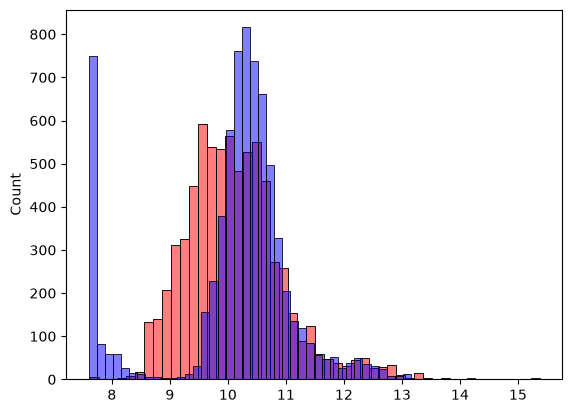

In [35]:
sns.histplot(pred, color = "red",alpha=0.5, bins = 50)
sns.histplot(y_train, color = "blue",alpha=0.5, bins = 50)

## Evaluating the Model: Root Mean Squared Error (RMSE)

To measure how well the linear regression model fits the data, we use the **Root Mean Squared Error (RMSE)**. It captures the typical size of the model's prediction errors, in the same units as the target variable.

$$
\text{RMSE} = \sqrt{\frac{1}{m} \sum_{i=1}^{m} \left( g(x_i) - y_i \right)^2}
$$

where:
- $m$ is the number of observations
- $g(x_i)$ is the model's prediction for observation $i$
- $y_i$ is the actual value for observation $i$

**How it's computed:**
1. **Error:** subtract the actual values from the predictions, $g(x_i) - y_i$
2. **Squared error:** square each error so positive and negative errors don't cancel out, and larger errors are penalized more heavily
3. **Mean squared error:** average the squared errors across all observations
4. **Root:** take the square root to return to the original units of $y$

**Interpretation:** lower RMSE means better predictions, and an RMSE of 0 would mean perfect predictions. Because errors are squared before averaging, RMSE is sensitive to outliers.

In [36]:
def RMSE(pred,y): 
    error_sq = (pred-y) ** 2
    mean_error_sq = error_sq.mean()
    return np.sqrt(mean_error_sq)

RMSE(pred,y_train)

np.float64(0.7377172987843197)

### Data Preparation: `data_prep(df)`

Builds the numeric feature matrix `X` from a car DataFrame.

**Features:** `engine_hp`, `engine_cylinders`, `number_of_doors`, `highway_mpg`, `city_mpg`, `popularity`, plus derived **`age`** = `max_year - year`.

**Steps:**
1. Copy `df` so the original is left unchanged
2. Add `age` using `max_year`, the newest year in the **training set**
3. Select `base + ['age']` and fill missing values with `0`
4. Return a NumPy array of shape `(n_rows, 7)`

**Why `max_year` comes from the training set:** it's computed once and reused for train, validation, and test, so `age` means the same thing in every split. Computing it inside the function would give each split its own reference year and inconsistent features.

**Note:** filling with `0` is simple but can bias fields like `engine_hp`; the training-set mean or median is an alternative.

In [37]:
base = ['engine_hp','engine_cylinders','number_of_doors','highway_mpg','city_mpg','popularity']
max_year = df.year.max()

def data_prep(df): 
    df = df.copy()
    
    df['age'] = max_year - df.year
    features = base + ['age']
    df_prep = df[features]
    df_prep = df_prep.fillna(0)
    X = df_prep.values
    return X

data_prep(df_val)

array([[ 563.,   12.,    4., ...,   13.,   86.,    3.],
       [ 200.,    4.,    4., ...,   22.,  873.,    0.],
       [ 200.,    4.,    4., ...,   19., 1385.,    2.],
       ...,
       [ 240.,    4.,    4., ...,   25.,  870.,    2.],
       [ 444.,    8.,    2., ...,   13.,  238.,    2.],
       [ 332.,    8.,    4., ...,   20., 1624.,    4.]], shape=(2382, 7))

In [38]:
X_train = data_prep(df_train)
wo,w = train_linear_regression(X_train,y_train)
X_train_pred = w0 + X_train.dot(w)

X_val = data_prep(df_val)
X_val_pred = w0 + X_val.dot(w)
RMSE(y_val,X_val_pred)

np.float64(2.2281563088827205)

<Axes: ylabel='Count'>

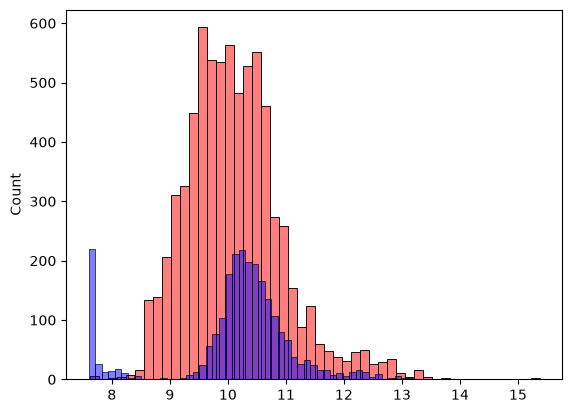

In [39]:
sns.histplot(pred, color = "red",alpha=0.5, bins = 50)
sns.histplot(y_val, color = "blue",alpha=0.5, bins = 50)

*Categorical Variables*

In [40]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [41]:
#df_train['num_doors_2'] = (df_train.number_of_doors == 2).astype('int')
#df_train['num_doors_3'] = (df_train.number_of_doors == 3).astype('int')
#df_train['num_doors_4'] = (df_train.number_of_doors == 4).astype('int')

#df_train = df_train.drop(columns='num_doors_4')
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7143,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61
7144,cadillac,dts,2010,premium_unleaded_(recommended),275.0,8.0,automatic,front_wheel_drive,4.0,luxury,large,sedan,23,15,1624
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873


In [47]:
df_train["number_of_doors"].value_counts(dropna=False)

number_of_doors
4.0    4998
2.0    1916
3.0     228
NaN       6
Name: count, dtype: int64

In [56]:
base

['engine_hp',
 'engine_cylinders',
 'number_of_doors',
 'highway_mpg',
 'city_mpg',
 'popularity']

In [68]:
categorical = {
    'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
    'engine_fuel_type': ['regular_unleaded', 'premium_unleaded_(required)',
                         'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)'],
    'transmission_type': ['automatic', 'manual', 'automated_manual'],
    'driven_wheels': ['front_wheel_drive', 'rear_wheel_drive',
                      'all_wheel_drive', 'four_wheel_drive'],
    'market_category': ['crossover', 'flex_fuel', 'luxury', 'luxury,performance', 'hatchback'],
    'vehicle_size': ['compact', 'midsize', 'large'],
    'vehicle_style': ['sedan', '4dr_suv', 'coupe', 'convertible', '4dr_hatchback'],
}
categorical

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)'],
 'transmission_type': ['automatic', 'manual', 'automated_manual'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [82]:
num_doors = [2,3,4]
for v in num_doors:
    df_train[f"number_doors_{v}"] = (df_train.number_of_doors == v).astype(int)
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,number_doors_2,number_doors_3,number_doors_4
0,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,1,0,0
1,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,0,0,1
2,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,0,0,1
3,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,0,1,0
4,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7143,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61,0,0,1
7144,cadillac,dts,2010,premium_unleaded_(recommended),275.0,8.0,automatic,front_wheel_drive,4.0,luxury,large,sedan,23,15,1624,0,0,1
7145,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,1,0,0
7146,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,1,0,0


In [91]:
make = list(df.make.value_counts().head().index)

In [ ]:
base = ['engine_hp','engine_cylinders','number_of_doors','highway_mpg','city_mpg','popularity']
max_year = df.year.max()

def data_prep(df): 
    df = df.copy()
    df['age'] = max_year - df.year
    features = base + ['age']

    num_doors = [2,3,4]
    for v in num_doors:
        df_train[f"number_doors_{v}"] = (df_train.number_of_doors == v).astype(int)
        features.append(f"number_doors_{v}")

    for v in make: 
        df_train[f"make_{v}"] = (df_train.make == v).astype(int)
        features.append(f"make_{v}")

    df_prep = df[features]
    df_prep = df_prep.fillna(0)
    X = df_prep.values
    return X

data_prep(df_val)

In [111]:
df.dtypes

AttributeError: 'Index' object has no attribute 'dtypes'